# 02 — Amostragem Estratificada

Gera uma amostra de **500 tweets** mantendo a proporção original das categorias.  
Saída: `data/sample/toldBr_sample_500.csv`

## 1. Carregamento

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

df = pl.read_csv('../data/raw/toldBr_full.csv')
print(f'Dataset completo: {df.shape[0]:,} tweets, {df.shape[1]} colunas')
print('Labels disponíveis:', sorted(df['label'].unique().to_list()))

Dataset completo: 21,000 tweets, 8 colunas
Labels disponíveis: ['homophobia', 'insult', 'misogyny', 'not_toxic', 'obscene', 'racism', 'xenophobia']


## 2. Amostragem estratificada

In [2]:
N_SAMPLE = 500
SEED = 42
n_total = df.height

# Calcula n por label proporcional ao dataset original
label_counts = df['label'].value_counts().sort('label')
print('Proporção original:')
print(
    label_counts.with_columns(
        (pl.col('count') / n_total * 100).round(2).alias('pct'),
        (pl.col('count') / n_total * N_SAMPLE).round(0).cast(pl.Int32).alias('n_amostra')
    )
)

Proporção original:
shape: (7, 4)
┌────────────┬───────┬───────┬───────────┐
│ label      ┆ count ┆ pct   ┆ n_amostra │
│ ---        ┆ ---   ┆ ---   ┆ ---       │
│ str        ┆ u32   ┆ f64   ┆ i32       │
╞════════════╪═══════╪═══════╪═══════════╡
│ homophobia ┆ 169   ┆ 0.8   ┆ 4         │
│ insult     ┆ 1502  ┆ 7.15  ┆ 36        │
│ misogyny   ┆ 44    ┆ 0.21  ┆ 1         │
│ not_toxic  ┆ 16937 ┆ 80.65 ┆ 403       │
│ obscene    ┆ 2296  ┆ 10.93 ┆ 55        │
│ racism     ┆ 21    ┆ 0.1   ┆ 0         │
│ xenophobia ┆ 31    ┆ 0.15  ┆ 1         │
└────────────┴───────┴───────┴───────────┘


In [3]:
# Amostragem estratificada com Polars
sample = (
    df
    .group_by('label')
    .map_groups(
        lambda g: g.sample(
            n=min(len(g), round(N_SAMPLE * len(g) / n_total)),
            seed=SEED
        )
    )
)

print(f'Amostra gerada: {sample.height} tweets')

Amostra gerada: 500 tweets


## 3. Verificação — distribuição da amostra vs. original

In [4]:
dist_orig = (
    df['label'].value_counts()
    .rename({'count': 'n_orig'})
    .with_columns((pl.col('n_orig') / n_total * 100).round(2).alias('pct_orig'))
)
dist_sample = (
    sample['label'].value_counts()
    .rename({'count': 'n_sample'})
    .with_columns((pl.col('n_sample') / sample.height * 100).round(2).alias('pct_sample'))
)

comparison = dist_orig.join(dist_sample, on='label', how='left').sort('n_orig', descending=True)
print('Comparação original vs. amostra:')
print(comparison)

Comparação original vs. amostra:
shape: (7, 5)
┌────────────┬────────┬──────────┬──────────┬────────────┐
│ label      ┆ n_orig ┆ pct_orig ┆ n_sample ┆ pct_sample │
│ ---        ┆ ---    ┆ ---      ┆ ---      ┆ ---        │
│ str        ┆ u32    ┆ f64      ┆ u32      ┆ f64        │
╞════════════╪════════╪══════════╪══════════╪════════════╡
│ not_toxic  ┆ 16937  ┆ 80.65    ┆ 403      ┆ 80.6       │
│ obscene    ┆ 2296   ┆ 10.93    ┆ 55       ┆ 11.0       │
│ insult     ┆ 1502   ┆ 7.15     ┆ 36       ┆ 7.2        │
│ homophobia ┆ 169    ┆ 0.8      ┆ 4        ┆ 0.8        │
│ misogyny   ┆ 44     ┆ 0.21     ┆ 1        ┆ 0.2        │
│ xenophobia ┆ 31     ┆ 0.15     ┆ 1        ┆ 0.2        │
│ racism     ┆ 21     ┆ 0.1      ┆ null     ┆ null       │
└────────────┴────────┴──────────┴──────────┴────────────┘


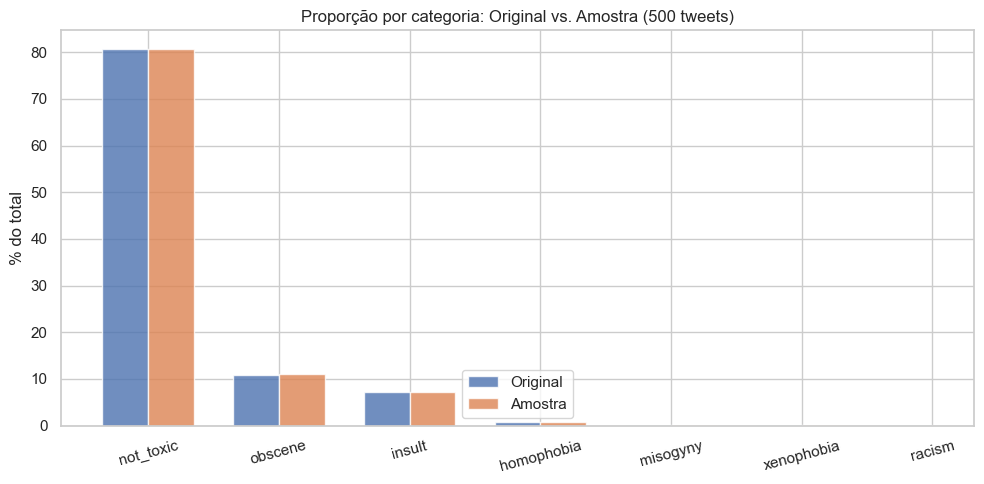

In [5]:
comp_pd = comparison.to_pandas()

x = range(len(comp_pd))
width = 0.35

fig, ax = plt.subplots()
ax.bar([i - width/2 for i in x], comp_pd['pct_orig'], width, label='Original', alpha=0.8)
ax.bar([i + width/2 for i in x], comp_pd['pct_sample'], width, label='Amostra', alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(comp_pd['label'], rotation=15)
ax.set_title('Proporção por categoria: Original vs. Amostra (500 tweets)')
ax.set_ylabel('% do total')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Exportação

In [6]:
OUT_PATH = '../data/sample/toldBr_sample_500.csv'
sample.write_csv(OUT_PATH)

# Verificação final
check = pl.read_csv(OUT_PATH)
print(f'Arquivo salvo: {OUT_PATH}')
print(f'Shape: {check.shape}')
print(f'Labels: {sorted(check["label"].unique().to_list())}')
check.head()

Arquivo salvo: ../data/sample/toldBr_sample_500.csv
Shape: (500, 8)
Labels: ['homophobia', 'insult', 'misogyny', 'not_toxic', 'obscene', 'xenophobia']


text,homophobia,obscene,insult,racism,misogyny,xenophobia,label
str,f64,f64,f64,f64,f64,f64,str
"""@user @user @user Se não fosse…",0.0,0.0,3.0,0.0,0.0,0.0,"""insult"""
"""vejo vídeos como esse e depois…",0.0,1.0,2.0,0.0,0.0,0.0,"""insult"""
"""@user @user Vai se lascar sua …",0.0,0.0,3.0,0.0,0.0,0.0,"""insult"""
"""rt @user ah vai tomar no cu""",0.0,0.0,2.0,0.0,0.0,0.0,"""insult"""
"""@user @user @user a feia lá kk…",0.0,0.0,2.0,0.0,0.0,0.0,"""insult"""
